In [46]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Refinement
Fonction qui va permettre de refine le topolical graphe initial, avec marge d'erreur de 2px

In [47]:
from skimage import io
from meta import ROOT_DIR
import matplotlib.pyplot as plt
import os
import numpy as np
from PIL import Image

from bez.topo_graph import extract_topology_from_skeleton, extract_simple_topology_from_skeleton, image_to_skeleton
from bez.refinement import  refine
from bez.hypergraph import HyperGraph
from bez.global_optim import optimisation
from bez.viz import visualize_topo, visualize_topo_and_save, visualize_graph_hypergraph

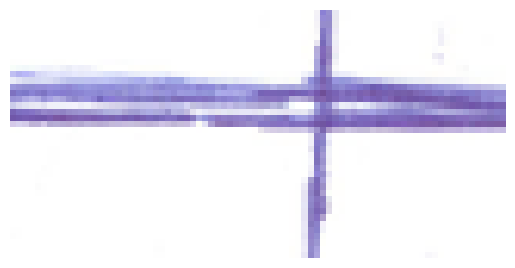

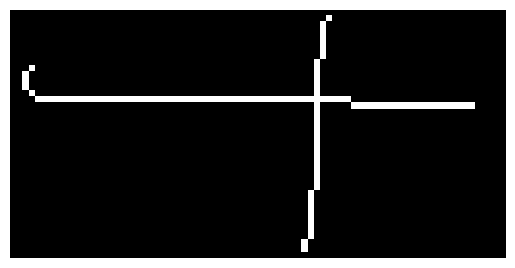

In [ ]:
# Skeleton extraction
img = io.imread(ROOT_DIR /"data/original_paper/figure_2/input.png") [170:210, 680:730, :]

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

skeletone, thikness = image_to_skeleton(img)


plt.imshow(skeletone, cmap="gray")  # ou cmap="binary", ou cmap="Greens", selon ce que tu veux
plt.axis("off")
plt.show()


rgba = np.zeros((skeletone.shape[0], skeletone.shape[1], 4), dtype=np.uint8)
rgba[skeletone] = [0, 0, 0, 255] 

out_path = ROOT_DIR / "images/squelette_transparent.png"
Image.fromarray(rgba).save(out_path)


In [49]:
topo_graph = extract_simple_topology_from_skeleton(skeletone)
topo_graph_ = extract_topology_from_skeleton(skeletone)
refined = refine(topo_graph)

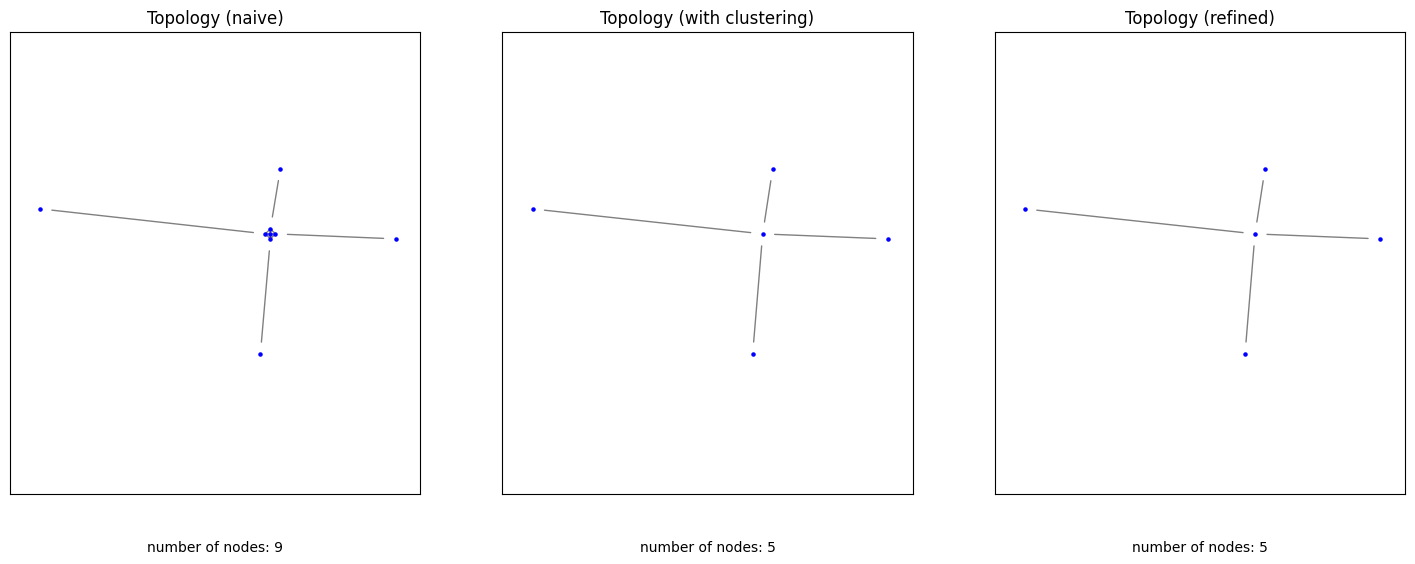

In [50]:
plt.figure(figsize=(18, 6))

ax = plt.subplot(1, 3, 1)
visualize_topo(topo_graph_)
plt.title("Topology (naive)")
ax.text(.5,-0.1,f"number of nodes: {len(topo_graph_.nodes())}", fontsize=10, ha='center', va='top', transform=ax.transAxes)

ax = plt.subplot(1, 3, 2)
visualize_topo(topo_graph)
plt.title("Topology (with clustering)")
ax.text(.5,-0.1,f"number of nodes: {len(topo_graph.nodes())}", fontsize=10, ha='center', va='top', transform=ax.transAxes)

ax = plt.subplot(1, 3, 3)
visualize_topo(refined)
plt.title("Topology (refined)")
ax.text(.5,-0.1,f"number of nodes: {len(refined.nodes())}", fontsize=10, ha='center', va='top', transform=ax.transAxes)


folder = os.path.join(ROOT_DIR /"images")
os.makedirs(folder, exist_ok=True)
save_path = os.path.join(folder, "topo_graph_evolution.png")

plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)

plt.show()



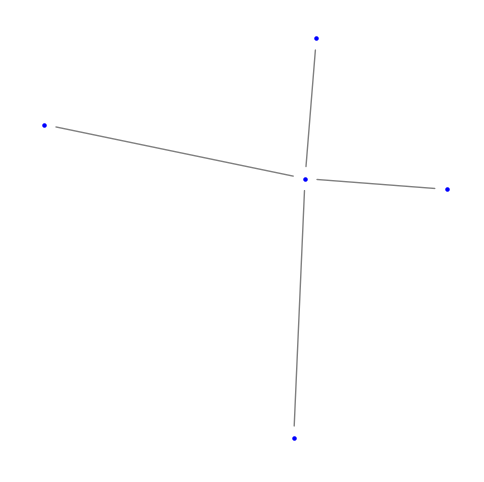

In [51]:
folder = os.path.join(ROOT_DIR /"images")
os.makedirs(folder, exist_ok=True)
save_path = os.path.join(folder, "refined_topo_graph.png")

visualize_topo_and_save(refined, save_path=save_path)

In [52]:
hyper = HyperGraph(refined)

# param
lam = 0.8
temp = 0.5
t_min = 0.05
mu = 0.3
t_decrease = 0.999 ** (1/len(refined.nodes))

In [53]:
error = optimisation(hyper, lam=lam, mu=mu, temp=temp, t_decrease=t_decrease, t_min=t_min)


100%|██████████| 11507/11507 [00:02<00:00, 5433.19it/s]


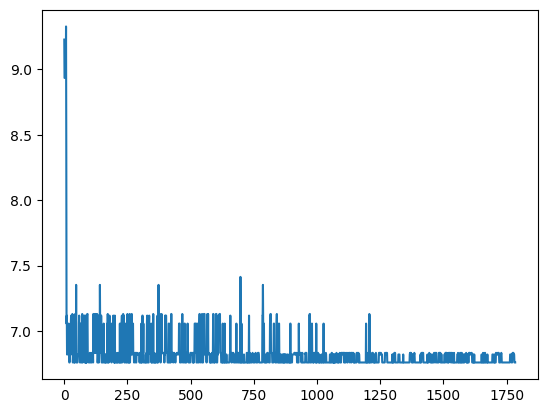

In [54]:
plt.plot(range(len(error)), error)

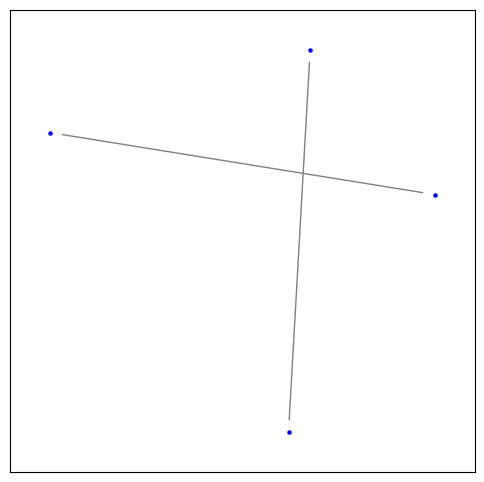

In [55]:
folder = os.path.join(ROOT_DIR /"images")
os.makedirs(folder, exist_ok=True)
save_path = os.path.join(folder, "hyper_graph.png")

visualize_graph_hypergraph(hyper, save_path=save_path)


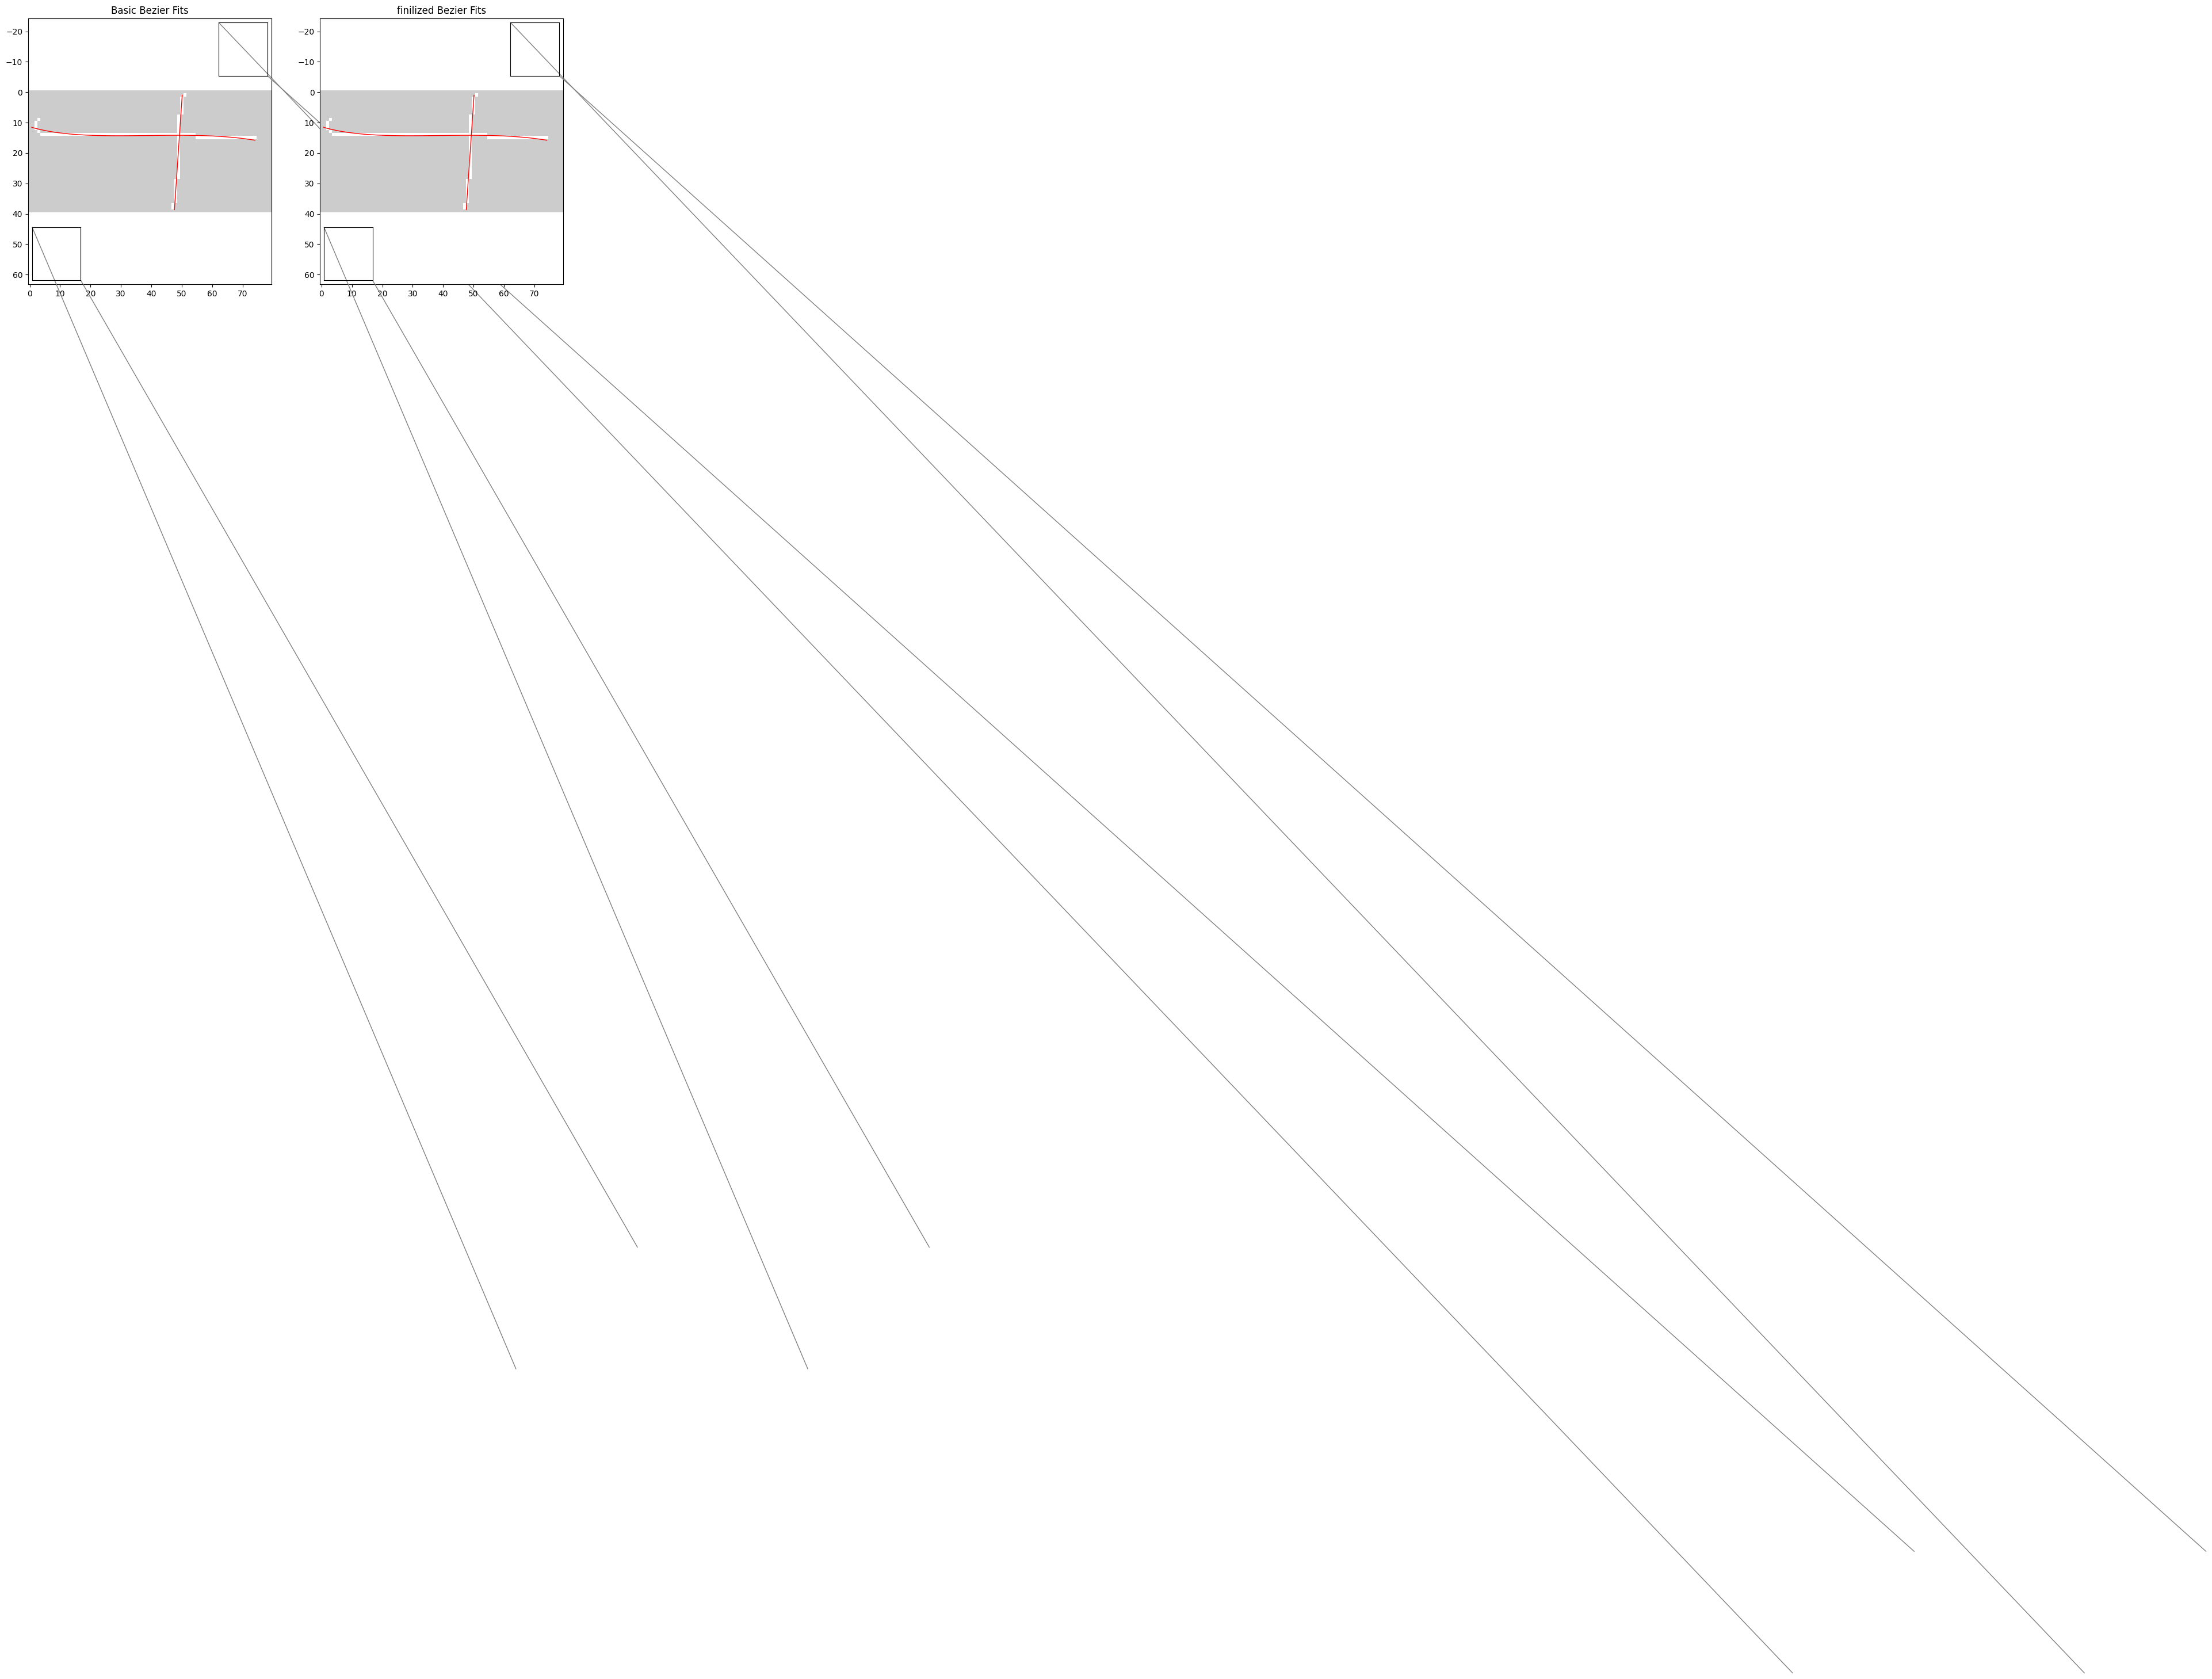

In [56]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

hyper.fit_beziers()

plt.figure(figsize=(12, 6))
# Superpose l'image originale

ax = plt.subplot(1, 2, 1)
plt.imshow(skeletone, cmap="gray", alpha=0.2)
hyper.visualize_fiting()
plt.axis("equal")
plt.title("Basic Bezier Fits")

axins1 = inset_axes(ax, width="20%", height="20%", loc="lower left")
hyper.visualize_fiting(axins1)
axins1.set_xlim(160, 200) 
axins1.set_ylim(380, 420)
axins1.get_xaxis().set_visible(False)
axins1.get_yaxis().set_visible(False)
axins1.invert_yaxis()
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="0.5")

axins2 = inset_axes(ax, width="20%", height="20%", loc="upper right")
hyper.visualize_fiting(axins2)
axins2.set_xlim(580, 620)
axins2.set_ylim(480, 520)
axins2.get_xaxis().set_visible(False)
axins2.get_yaxis().set_visible(False)
axins2.invert_yaxis()
mark_inset(ax, axins2, loc1=2, loc2=4, fc="none", ec="0.5")

hyper.finition()

ax = plt.subplot(1, 2, 2)
plt.imshow(skeletone, cmap="gray", alpha=0.2)
hyper.visualize_fiting()
plt.axis("equal")
plt.title("finilized Bezier Fits") 

axins1 = inset_axes(ax, width="20%", height="20%", loc="lower left")
hyper.visualize_fiting(axins1)
axins1.set_xlim(160, 200) 
axins1.set_ylim(380, 420)
axins1.get_xaxis().set_visible(False)
axins1.get_yaxis().set_visible(False)
axins1.invert_yaxis()
mark_inset(ax, axins1, loc1=2, loc2=4, fc="none", ec="0.5")

axins2 = inset_axes(ax, width="20%", height="20%", loc="upper right")
hyper.visualize_fiting(axins2)
axins2.set_xlim(580, 620)
axins2.set_ylim(480, 520)
axins2.get_xaxis().set_visible(False)
axins2.get_yaxis().set_visible(False)
axins2.invert_yaxis()
mark_inset(ax, axins2, loc1=2, loc2=4, fc="none", ec="0.5")


folder = os.path.join(ROOT_DIR /"images")
os.makedirs(folder, exist_ok=True)
save_path = os.path.join(folder, "topo_graph_evolution.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0, transparent=True)

plt.show()
